### Load Dataset of 20 super classes classes from cifar 100

trainX.shape: (50000, 32, 32, 3), trainY.shape: (50000, 1), testX.shape: (10000, 32, 32, 3), testY.shape: (10000, 1)
trainX.dtype: uint8, trainY.dtype: int32, testX.dtype: uint8, testY.dtype: int32
trainX.Range: 255 - 0, testX.Range: 255 - 0


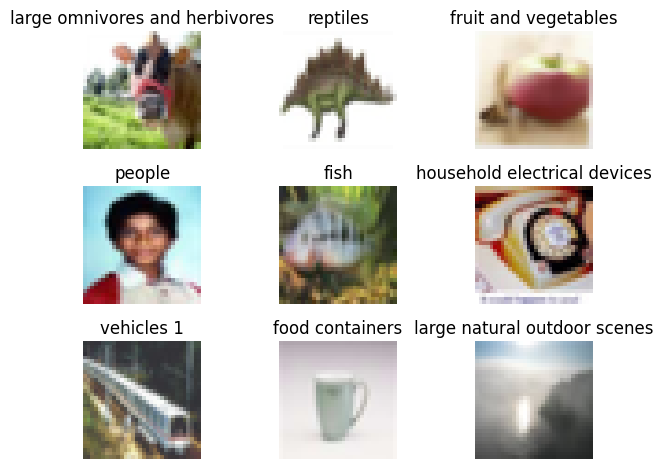

In [10]:
from keras.datasets import cifar100
from keras.utils import to_categorical
import matplotlib.pyplot as plt
import numpy as np

def display_img(img_set, title_set):
    n = len(title_set)
    for i in range(n):
        plt.subplot(3, 3, i + 1)
        plt.imshow(img_set[i])
        plt.title(title_set[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Load CIFAR-100 with coarse labels (20 classes)
(trainX, trainY), (testX, testY) = cifar100.load_data(label_mode='coarse')

# Investigate loaded data
print('trainX.shape: {}, trainY.shape: {}, testX.shape: {}, testY.shape: {}'.format(trainX.shape, trainY.shape, testX.shape, testY.shape))
print('trainX.dtype: {}, trainY.dtype: {}, testX.dtype: {}, testY.dtype: {}'.format(trainX.dtype, trainY.dtype, testX.dtype, testY.dtype))
print('trainX.Range: {} - {}, testX.Range: {} - {}'.format(trainX.max(), trainX.min(), testX.max(), testX.min()))

# Optional: Map class indices to class names
coarse_label_names = [
    'aquatic mammals', 'fish', 'flowers', 'food containers', 'fruit and vegetables',
    'household electrical devices', 'household furniture', 'insects', 'large carnivores',
    'large man-made outdoor things', 'large natural outdoor scenes', 'large omnivores and herbivores',
    'medium-sized mammals', 'non-insect invertebrates', 'people', 'reptiles',
    'small mammals', 'trees', 'vehicles 1', 'vehicles 2'
]

# Display first 9 images with their class names
display_img(trainX[:9], [coarse_label_names[label[0]] for label in trainY[:9]])


### Pre Process the data

In [11]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar100

# Normalize the pixel values to [0, 1]
trainX = trainX.astype('float32') / 255.0
testX = testX.astype('float32') / 255.0

# Resize images to 96x96 (required by most ImageNet pre-trained models)
trainX = tf.image.resize(trainX, (96, 96))
testX = tf.image.resize(testX, (96, 96))

# Convert labels to one-hot encoding (20 classes)
trainY = to_categorical(trainY, num_classes=20)
testY = to_categorical(testY, num_classes=20)

# Print data shapes and types
print(f"trainX.shape: {trainX.shape}, testX.shape: {testX.shape}")
print(f"trainX.dtype: {trainX.dtype}, testX.dtype: {testX.dtype}")
print(f"trainY.shape: {trainY.shape}, testY.shape: {testY.shape}")
print(f"trainY.dtype: {trainY.dtype}, testY.dtype: {testY.dtype}")

# Check sample labels
print("Sample trainY (one-hot encoded):")
print(trainY[:5])


trainX.shape: (50000, 96, 96, 3), testX.shape: (10000, 96, 96, 3)
trainX.dtype: <dtype: 'float32'>, testX.dtype: <dtype: 'float32'>
trainY.shape: (50000, 20), testY.shape: (10000, 20)
trainY.dtype: float64, testY.dtype: float64
Sample trainY (one-hot encoded):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


## To load exactly the 20 fine labeled class from the cifar 100

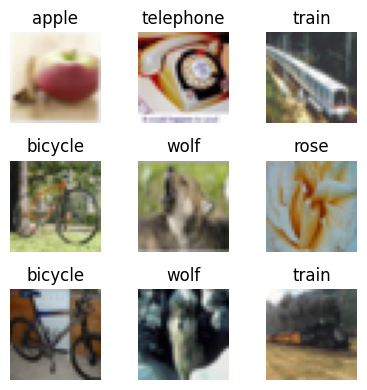

In [12]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.datasets import cifar100
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# Load CIFAR-100 with fine labels
(trainX_all, trainY_all), (testX_all, testY_all) = cifar100.load_data(label_mode='fine')

# Define 20 selected class names
selected_classes = [
    'beaver', 'dolphin', 'otter', 'seal', 'whale',
    'bear', 'tiger', 'lion', 'wolf', 'fox',
    'apple', 'orange', 'pear', 'rose', 'tulip',
    'bicycle', 'motorcycle', 'train', 'rocket', 'telephone'
]

# Full CIFAR-100 fine label names (in order)
all_fine_labels = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle',
    'bicycle', 'bottle', 'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel',
    'can', 'castle', 'caterpillar', 'cattle', 'chair', 'chimpanzee', 'clock',
    'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup', 'dinosaur',
    'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster',
    'house', 'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion',
    'lizard', 'lobster', 'man', 'maple_tree', 'motorcycle', 'mountain', 'mouse',
    'mushroom', 'oak_tree', 'orange', 'orchid', 'otter', 'palm_tree', 'pear',
    'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose',
    'sea', 'seal', 'shark', 'shrew', 'skunk', 'skyscraper', 'snail', 'snake',
    'spider', 'squirrel', 'streetcar', 'sunflower', 'sweet_pepper', 'table',
    'tank', 'telephone', 'television', 'tiger', 'tractor', 'train', 'trout',
    'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman',
    'worm'
]

# Get indices for selected classes
selected_indices = [all_fine_labels.index(cls) for cls in selected_classes]

# Filter function
def filter_data(X, Y, class_indices):
    mask = np.isin(Y.flatten(), class_indices)
    X_filtered = X[mask]
    Y_filtered = Y[mask]
    label_map = {orig: new for new, orig in enumerate(class_indices)}
    Y_remapped = np.array([label_map[y[0]] for y in Y_filtered]).reshape(-1, 1)
    return X_filtered, Y_remapped

# Apply filtering to training and test sets
trainX_filtered, trainY_filtered = filter_data(trainX_all, trainY_all, selected_indices)
testX_filtered, testY_filtered = filter_data(testX_all, testY_all, selected_indices)

#  Display function
def display_img(img_set, label_set, class_names, n=9):
    plt.figure(figsize=(4, 4))
    for i in range(n):
        plt.subplot(3, 3, i + 1)
        plt.imshow(img_set[i])
        plt.title(class_names[label_set[i][0]])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Show first 9 filtered images
display_img(trainX_filtered, trainY_filtered, selected_classes)


## Preprocess the data

In [13]:
from tensorflow.image import resize

# Normalize to [0, 1]
trainX_filtered = trainX_filtered.astype('float32') / 255.0
testX_filtered = testX_filtered.astype('float32') / 255.0

# Resize to 96x96x3
trainX_filtered = resize(trainX_filtered, (96, 96))
testX_filtered = resize(testX_filtered, (96, 96))

# One-hot encode labels (20 classes)
trainY_filtered = to_categorical(trainY_filtered, num_classes=20)
testY_filtered = to_categorical(testY_filtered, num_classes=20)

# Final training data
trainX = trainX_filtered
trainY = trainY_filtered
testX = testX_filtered
testY = testY_filtered

# Print data shapes and types
print(f"trainX.shape: {trainX.shape}, testX.shape: {testX.shape}")
print(f"trainX.dtype: {trainX.dtype}, testX.dtype: {testX.dtype}")
print(f"trainY.shape: {trainY.shape}, testY.shape: {testY.shape}")
print(f"trainY.dtype: {trainY.dtype}, testY.dtype: {testY.dtype}")

# Check sample labels
print("Sample trainY (one-hot encoded):")
print(trainY[:5])


trainX.shape: (10000, 96, 96, 3), testX.shape: (2000, 96, 96, 3)
trainX.dtype: <dtype: 'float32'>, testX.dtype: <dtype: 'float32'>
trainY.shape: (10000, 20), testY.shape: (2000, 20)
trainY.dtype: float64, testY.dtype: float64
Sample trainY (one-hot encoded):
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


### 1. MobileNet

In [14]:
from tensorflow.keras.applications import MobileNet
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, BatchNormalization, Dropout
from tensorflow.keras.models import Model
import time
# Load pre-trained MobileNet with input shape 96x96x3
mobilenet = MobileNet(input_shape=(96, 96, 3), include_top=False, weights='imagenet')

# Freeze all layers in the MobileNet backbone
for layer in mobilenet.layers:
    layer.trainable = False

# Build classification head for 20 classes
inputs_mobilenet = mobilenet.input
x = mobilenet.output

x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs_final = Dense(20, activation='softmax', name='OutputLayer')(x)

# Create the model
model = Model(inputs=inputs_mobilenet, outputs=outputs_final, name='MobileNet_CIFAR100_20Classes')

# Print model summary
model.summary()


C:\Users\User\AppData\Local\Temp\ipykernel_11600\3520486571.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  mobilenet = MobileNet(input_shape=(96, 96, 3), include_top=False, weights='imagenet')


Model: "MobileNet_CIFAR100_20Classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 48, 48, 32)     │           864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_bn (BatchNormalization)   │ (None, 48, 48, 32)     │           128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1_relu (ReLU)               │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1 (DepthwiseConv2D)     │ (None, 48, 48, 32)     │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_bn                    │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_1_relu (ReLU)           │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1 (Conv2D)              │ (None, 48, 48, 64)     │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_bn                    │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_1_relu (ReLU)           │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pad_2 (ZeroPadding2D)      │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2 (DepthwiseConv2D)     │ (None, 24, 24, 64)     │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_bn                    │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_2_relu (ReLU)           │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2 (Conv2D)              │ (None, 24, 24, 128)    │         8,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_2_relu (ReLU)           │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3 (DepthwiseConv2D)     │ (None, 24, 24, 128)    │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_dw_3_relu (ReLU)           │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3 (Conv2D)              │ (None, 24, 24, 128)    │        16,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv_pw_3_bn                    │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 4,819,668 (18.39 MB)

 Trainable params: 1,587,732 (6.06 MB)

 Non-trainable params: 3,231,936 (12.33 MB)

### Transfer Learning

In [15]:
import tensorflow as tf

# Compile the model for Transfer Learning
# (only the new classification head will be trained since MobileNet layers are frozen)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train only the classification head
history_transfer_learning = model.fit(
    trainX, trainY,
    batch_size=64,
    validation_split=0.1,
    epochs=10,
    verbose=1
)

# Evaluate on the test set
start_time = time.time()
t_loss, t_acc = model.evaluate(testX, testY, verbose=0)
end_time = time.time()
inference_time = end_time - start_time
print(f"📊 Transfer Learning Test Accuracy: {t_acc:.4f}")
print(f"📊 Inference time: {inference_time:.4f}")


Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 62ms/step - accuracy: 0.4529 - loss: 2.0716 - val_accuracy: 0.7080 - val_loss: 0.8985
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.7096 - loss: 0.9058 - val_accuracy: 0.7070 - val_loss: 0.8614
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.7441 - loss: 0.7585 - val_accuracy: 0.7150 - val_loss: 0.8387
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.7980 - loss: 0.5998 - val_accuracy: 0.7250 - val_loss: 0.8550
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.8132 - loss: 0.5387 - val_accuracy: 0.7110 - val_loss: 0.8406
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 58ms/step - accuracy: 0.8413 - loss: 0.4624 - val_accuracy: 0.7270 - val_loss: 0.9020
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 8s 59ms/step - accuracy: 0.8610 - loss: 0.4009 - val_accuracy: 0.7130 - val_loss: 0.9042
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 9s 61ms/step - accuracy: 0.8756 - loss: 0.3678 - val_acc

### 2. VGG 16 Model

In [16]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization
import time
# Load pre-trained VGG16 model, excluding the top classification layers
vgg_base = VGG16(input_shape=(96, 96, 3), include_top=False, weights='imagenet')

# Freeze all layers in VGG16
for layer in vgg_base.layers:
    layer.trainable = False

# Add custom classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(20, activation='softmax', name='OutputLayer')(x)

# Final model
model_vgg16 = Model(inputs=vgg_base.input, outputs=outputs, name='VGG16_CIFAR100_20Classes')
model_vgg16.summary()


Model: "VGG16_CIFAR100_20Classes"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 96, 96, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 96, 96, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 48, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 48, 48, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 48, 48, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 24, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1024)           │         4,096 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 512)            │       524,80

 Total params: 15,781,204 (60.20 MB)

 Trainable params: 1,063,444 (4.06 MB)

 Non-trainable params: 14,717,760 (56.14 MB)

In [17]:
# Compile the model for transfer learning
model_vgg16.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train only the new head
history_vgg_transfer = model_vgg16.fit(
    trainX, trainY,
    batch_size=64,
    validation_split=0.1,
    epochs=10,
    verbose=1
)

# Evaluate
start_time = time.time()
vgg_transfer_loss, vgg_transfer_acc = model_vgg16.evaluate(testX, testY, verbose=0)
end_time = time.time()
inference_time = end_time - start_time
print(f"📊 VGG16 Transfer Learning Test Accuracy: {vgg_transfer_acc:.4f}")
print(f"📊 Inference time: {inference_time:.4f}")

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 36s 247ms/step - accuracy: 0.2967 - loss: 2.7108 - val_accuracy: 0.3760 - val_loss: 2.0760
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 249ms/step - accuracy: 0.4868 - loss: 1.6913 - val_accuracy: 0.5170 - val_loss: 1.5574
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 249ms/step - accuracy: 0.5271 - loss: 1.5104 - val_accuracy: 0.5600 - val_loss: 1.3458
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 249ms/step - accuracy: 0.5497 - loss: 1.3884 - val_accuracy: 0.5790 - val_loss: 1.2967
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 250ms/step - accuracy: 0.5706 - loss: 1.3093 - val_accuracy: 0.5990 - val_loss: 1.3027
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 248ms/step - accuracy: 0.6045 - loss: 1.1955 - val_accuracy: 0.5580 - val_loss: 1.3815
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 251ms/step - accuracy: 0.6182 - loss: 1.1484 - val_accuracy: 0.5840 - val_loss: 1.2776
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 35s 251ms/step - accuracy: 0.6217 - loss: 1

### 3. ResNet50

In [18]:
from tensorflow.keras.applications import ResNet101
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Load pre-trained ResNet50 without top layers
resnet_base = ResNet101(input_shape=(96, 96, 3), include_top=False, weights='imagenet')

# Freeze base model
for layer in resnet_base.layers:
    layer.trainable = False

# Add custom head
x = resnet_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(20, activation='softmax')(x)

model_resnet = Model(inputs=resnet_base.input, outputs=outputs, name='ResNet50_CIFAR100_20')
model_resnet.summary()


Model: "ResNet50_CIFAR100_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 102, 102,  │          0 │ input_layer_4[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 48, 48,    │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 48, 48,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 48, 48,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 50, 50,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 24, 24,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 24, 24,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 24, 24,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 24, 24,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 24, 24,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 24, 24,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 24, 24,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 24, 24,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 24, 24,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 24, 24,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 24, 24,    │      1,024 │ conv2_block1_3_c

 Total params: 45,297,556 (172.80 MB)

 Trainable params: 2,636,308 (10.06 MB)

 Non-trainable params: 42,661,248 (162.74 MB)

In [19]:
model_resnet.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                     loss='categorical_crossentropy', metrics=['accuracy'])

history_resnet_transfer = model_resnet.fit(trainX, trainY, batch_size=64,
                                           validation_split=0.1, epochs=10, verbose=1)

start_time = time.time()
resnet_transfer_loss, resnet_transfer_acc = model_resnet.evaluate(testX, testY, verbose=0)
end_time = time.time()
inference_time = end_time - start_time
print(f"📊 ResNet50 Transfer Learning Accuracy: {resnet_transfer_acc:.4f}")
print(f"📊 Inference time: {inference_time:.4f}")

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 47s 293ms/step - accuracy: 0.1166 - loss: 3.7598 - val_accuracy: 0.0840 - val_loss: 2.9815
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 37s 262ms/step - accuracy: 0.1704 - loss: 3.0261 - val_accuracy: 0.0820 - val_loss: 2.8695
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 37s 266ms/step - accuracy: 0.2015 - loss: 2.8075 - val_accuracy: 0.0740 - val_loss: 2.8739
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 283ms/step - accuracy: 0.2238 - loss: 2.6456 - val_accuracy: 0.0950 - val_loss: 3.7107
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 280ms/step - accuracy: 0.2412 - loss: 2.5496 - val_accuracy: 0.1350 - val_loss: 3.7019
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 38s 271ms/step - accuracy: 0.2547 - loss: 2.4583 - val_accuracy: 0.1270 - val_loss: 3.4916
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 38s 271ms/step - accuracy: 0.2741 - loss: 2.4115 - val_accuracy: 0.2270 - val_loss: 2.7213
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 282ms/step - accuracy: 0.2798 - loss: 2

### 4. InceptionV3

In [20]:
from tensorflow.keras.applications import InceptionV3

inception_base = InceptionV3(input_shape=(96, 96, 3), include_top=False, weights='imagenet')

for layer in inception_base.layers:
    layer.trainable = False

x = inception_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(20, activation='softmax')(x)

model_inception = Model(inputs=inception_base.input, outputs=outputs, name='InceptionV3_CIFAR100_20')
model_inception.summary()


Model: "InceptionV3_CIFAR100_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 47, 47,    │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 47,    │         96 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 47, 47,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 45, 45,    │      9,216 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 45,    │         96 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 45, 45,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 45, 45,    │     18,432 │ activation_1[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 45,    │        192 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 45, 45,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 22, 22,    │          0 │ activation_2[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 22, 22,    │      5,120 │ max_pooling2d[0]… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 22, 22,    │        240 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 22, 22,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 20, 20,    │    138,240 │ activation_3[0][… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 20,    │        576 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 20, 20,    │          0 │ batch_normalizat

 Total params: 24,442,164 (93.24 MB)

 Trainable params: 2,636,308 (10.06 MB)

 Non-trainable params: 21,805,856 (83.18 MB)

In [21]:
model_inception.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
                        loss='categorical_crossentropy', metrics=['accuracy'])

history_inception_transfer = model_inception.fit(trainX, trainY, batch_size=64,
                                                 validation_split=0.1, epochs=10, verbose=1)

start_time = time.time()
inception_transfer_loss, inception_transfer_acc = model_inception.evaluate(testX, testY, verbose=0)
end_time = time.time()
inference_time = end_time - start_time
print(f"📊 InceptionV3 Transfer Learning Accuracy: {inception_transfer_acc:.4f}")
print(f"📊 Inference time: {inference_time:.4f}")

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 15s 85ms/step - accuracy: 0.3322 - loss: 2.6611 - val_accuracy: 0.5410 - val_loss: 1.5284
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.5494 - loss: 1.4586 - val_accuracy: 0.5520 - val_loss: 1.4326
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.5905 - loss: 1.2621 - val_accuracy: 0.5680 - val_loss: 1.4095
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 74ms/step - accuracy: 0.6438 - loss: 1.0729 - val_accuracy: 0.5720 - val_loss: 1.3624
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 76ms/step - accuracy: 0.6723 - loss: 0.9867 - val_accuracy: 0.5720 - val_loss: 1.3586
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.7013 - loss: 0.8821 - val_accuracy: 0.5930 - val_loss: 1.3936
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 74ms/step - accuracy: 0.7236 - loss: 0.8062 - val_accuracy: 0.5960 - val_loss: 1.3526
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 11s 75ms/step - accuracy: 0.7381 - loss: 0.7766 - 

### 5. InceptionResNetV2

In [22]:
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Load the InceptionResNetV2 base
base_model = InceptionResNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(20, activation='softmax')(x)  # 20-class output

model_incepresnet = Model(inputs=base_model.input, outputs=predictions)
model_incepresnet.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_94 (Conv2D)  │ (None, 47, 47,    │        864 │ input_layer_6[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 47, 47,    │         96 │ conv2d_94[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_94       │ (None, 47, 47,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_95 (Conv2D)  │ (None, 45, 45,    │      9,216 │ activation_94[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 45,    │         96 │ conv2d_95[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_95       │ (None, 45, 45,    │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_96 (Conv2D)  │ (None, 45, 45,    │     18,432 │ activation_95[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 45, 45,    │        192 │ conv2d_96[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_96       │ (None, 45, 45,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 22, 22,    │          0 │ activation_96[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_97 (Conv2D)  │ (None, 22, 22,    │      5,120 │ max_pooling2d_4[… │
│                     │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 22, 22,    │        240 │ conv2d_97[0][0]   │
│ (BatchNormalizatio… │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_97       │ (None, 22, 22,    │          0 │ batch_normalizat… │
│ (Activation)        │ 80)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_98 (Conv2D)  │ (None, 20, 20,    │    138,240 │ activation_97[0]… │
│                     │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 20,    │        576 │ conv2d_98[0][0]   │
│ (BatchNormalizatio… │ 192)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_98       │ (None, 20, 20,    │          0 │ batch_normalizat

 Total params: 56,451,828 (215.35 MB)

 Trainable params: 2,112,020 (8.06 MB)

 Non-trainable params: 54,339,808 (207.29 MB)

In [23]:
model_incepresnet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = model_incepresnet.fit(
    trainX, trainY,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)
start_time = time.time()
transfer_loss, transfer_acc = model_incepresnet.evaluate(testX, testY, verbose=0)
end_time = time.time()
inference_time = end_time - start_time
print(f"📊 InceptionResNetV2 Transfer Learning Accuracy: {transfer_acc:.4f}")
print(f"📊 Inference time: {inference_time:.4f}")

Epoch 1/10


141/141 ━━━━━━━━━━━━━━━━━━━━ 36s 207ms/step - accuracy: 0.3714 - loss: 2.3857 - val_accuracy: 0.6180 - val_loss: 1.3224
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 27s 189ms/step - accuracy: 0.5815 - loss: 1.3478 - val_accuracy: 0.6340 - val_loss: 1.1430
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 27s 190ms/step - accuracy: 0.6249 - loss: 1.1583 - val_accuracy: 0.6430 - val_loss: 1.0820
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 27s 189ms/step - accuracy: 0.6657 - loss: 1.0339 - val_accuracy: 0.6450 - val_loss: 1.1076
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step - accuracy: 0.6837 - loss: 0.9609 - val_accuracy: 0.6450 - val_loss: 1.0587
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step - accuracy: 0.7225 - loss: 0.8330 - val_accuracy: 0.6380 - val_loss: 1.0716
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 27s 190ms/step - accuracy: 0.7423 - loss: 0.7674 - val_accuracy: 0.6620 - val_loss: 1.0912
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 186ms/step - accuracy: 0.7455 - loss: 0.7482 - val

### 6. MobileNetV2

In [24]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Load MobileNetV2 base model
base_model = MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(20, activation='softmax')(x)  # 20 classes

model_mobilenetv2 = Model(inputs=base_model.input, outputs=predictions)
model_mobilenetv2.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 48, 48,    │        864 │ input_layer_7[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 48, 48,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 48, 48,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 48, 48,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 48, 48,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 48, 48,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 48, 48,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 48, 48,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 49, 49,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 24, 24,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 24, 24,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 24, 24,    │      2,304 │ block_1_depthwis

 Total params: 4,110,932 (15.68 MB)

 Trainable params: 1,849,876 (7.06 MB)

 Non-trainable params: 2,261,056 (8.63 MB)

In [25]:
model_mobilenetv2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = model_mobilenetv2.fit(
    trainX, trainY,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)
start_time = time.time()
transfer_loss, transfer_acc = model_mobilenetv2.evaluate(testX, testY, verbose=0)
end_time = time.time()
inference_time = end_time - start_time
print(f"📊 MobileNetV2 Transfer Learning Accuracy: {transfer_acc:.4f}")
print(f"📊 Inference time: {inference_time:.4f}")

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 75ms/step - accuracy: 0.4424 - loss: 2.0881 - val_accuracy: 0.6670 - val_loss: 1.0087
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.6489 - loss: 1.1055 - val_accuracy: 0.6990 - val_loss: 0.9149
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.7072 - loss: 0.8971 - val_accuracy: 0.7100 - val_loss: 0.8823
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 70ms/step - accuracy: 0.7407 - loss: 0.7718 - val_accuracy: 0.7250 - val_loss: 0.8243
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.7672 - loss: 0.6915 - val_accuracy: 0.7170 - val_loss: 0.8275
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.7833 - loss: 0.6381 - val_accuracy: 0.7140 - val_loss: 0.8319
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.7948 - loss: 0.5913 - val_accuracy: 0.7320 - val_loss: 0.8454
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 10s 71ms/step - accuracy: 0.8053 - loss: 0.5588 - 

### 7. DenseNet121

In [26]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Load DenseNet121 base model
base_model = DenseNet121(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(20, activation='softmax')(x)

model_densenet = Model(inputs=base_model.input, outputs=predictions)
model_densenet.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 102, 102,  │          0 │ input_layer_8[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 48, 48,    │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 48, 48,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 48, 48,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 50, 50,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 24, 24,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 24, 24,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 24, 24,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 24, 24,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 24, 24,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 24, 24,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 24, 24,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 24, 24,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 24, 24,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 24, 24,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 24, 24,    │     12,288 │ conv2_block2_0_r

 Total params: 8,628,308 (32.91 MB)

 Trainable params: 1,587,732 (6.06 MB)

 Non-trainable params: 7,040,576 (26.86 MB)

In [27]:
model_densenet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = model_densenet.fit(
    trainX, trainY,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)
start_time = time.time()
transfer_loss, transfer_acc = model_densenet.evaluate(testX, testY, verbose=0)
end_time = time.time()
inference_time = end_time - start_time
print(f"📊 DenseNet121 Transfer Learning Accuracy: {transfer_acc:.4f}")
print(f"📊 Inference time: {inference_time:.4f}")

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 33s 196ms/step - accuracy: 0.4197 - loss: 2.1945 - val_accuracy: 0.6600 - val_loss: 1.0431
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 180ms/step - accuracy: 0.6508 - loss: 1.0823 - val_accuracy: 0.6930 - val_loss: 0.9521
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.6836 - loss: 0.9378 - val_accuracy: 0.6900 - val_loss: 0.9074
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 179ms/step - accuracy: 0.7312 - loss: 0.8037 - val_accuracy: 0.7180 - val_loss: 0.8627
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 181ms/step - accuracy: 0.7511 - loss: 0.7365 - val_accuracy: 0.7420 - val_loss: 0.8405
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 181ms/step - accuracy: 0.7844 - loss: 0.6270 - val_accuracy: 0.7090 - val_loss: 0.8857
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 183ms/step - accuracy: 0.7857 - loss: 0.6216 - val_accuracy: 0.7220 - val_loss: 0.8500
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 25s 178ms/step - accuracy: 0.7971 - loss: 0

### 8. DenseNet201

In [28]:
from tensorflow.keras.applications import DenseNet201
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Load DenseNet201 base model
base_model = DenseNet201(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(20, activation='softmax')(x)  # 20-class output

model_densenet201 = Model(inputs=base_model.input, outputs=predictions)
model_densenet201.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 102, 102,  │          0 │ input_layer_9[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 48, 48,    │      9,408 │ zero_padding2d_2… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 48, 48,    │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 48, 48,    │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_3    │ (None, 50, 50,    │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 24, 24,    │          0 │ zero_padding2d_3… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 24, 24,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 24, 24,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 24, 24,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 24, 24,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 24, 24,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 24, 24,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 24, 24,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 24, 24,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 24, 24,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 24, 24,    │     12,288 │ conv2_block2_0_r

 Total params: 20,830,292 (79.46 MB)

 Trainable params: 2,505,236 (9.56 MB)

 Non-trainable params: 18,325,056 (69.90 MB)

In [29]:
model_densenet201.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = model_densenet201.fit(
    trainX, trainY,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)
start_time = time.time()
transfer_loss, transfer_acc = model_densenet201.evaluate(testX, testY, verbose=0)
end_time = time.time()
inference_time = end_time - start_time
print(f"📊 DenseNet201 Transfer Learning Accuracy: {transfer_acc:.4f}")
print(f"📊 Inference time: {inference_time:.4f}")

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 53s 315ms/step - accuracy: 0.4402 - loss: 2.0960 - val_accuracy: 0.6820 - val_loss: 0.9711
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 39s 275ms/step - accuracy: 0.6725 - loss: 1.0187 - val_accuracy: 0.7110 - val_loss: 0.8906
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 38s 270ms/step - accuracy: 0.7204 - loss: 0.8514 - val_accuracy: 0.7220 - val_loss: 0.8503
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 284ms/step - accuracy: 0.7593 - loss: 0.7127 - val_accuracy: 0.7280 - val_loss: 0.8043
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 41s 288ms/step - accuracy: 0.7809 - loss: 0.6323 - val_accuracy: 0.7290 - val_loss: 0.8119
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 283ms/step - accuracy: 0.8128 - loss: 0.5546 - val_accuracy: 0.7340 - val_loss: 0.8286
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 285ms/step - accuracy: 0.8141 - loss: 0.5347 - val_accuracy: 0.7400 - val_loss: 0.7779
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 40s 285ms/step - accuracy: 0.8423 - loss: 0

### Xception

In [30]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Load DenseNet201 base model
base_model = Xception(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(20, activation='softmax')(x)  # 20-class output

model_xception = Model(inputs=base_model.input, outputs=predictions)
model_xception.summary()


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 47, 47,    │        864 │ input_layer_10[0… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 47, 47,    │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 47, 47,    │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 45, 45,    │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 45, 45,    │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 45, 45,    │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 45, 45,    │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 45, 45,    │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 45, 45,    │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 45, 45,    │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 45, 45,    │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_297 (Conv2D) │ (None, 23, 23,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 23, 23,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 23, 23,    │        512 │ conv2d_297[0][0]  │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 23, 23,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 23, 23,    │          0 │ add[0][0]       

 Total params: 23,500,860 (89.65 MB)

 Trainable params: 2,636,308 (10.06 MB)

 Non-trainable params: 20,864,552 (79.59 MB)

In [31]:
model_xception.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = model_xception.fit(
    trainX, trainY,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)
start_time = time.time()
transfer_loss, transfer_acc = model_xception.evaluate(testX, testY, verbose=0)
end_time = time.time()
inference_time = end_time - start_time
print(f"📊 Xception Transfer Learning Accuracy: {transfer_acc:.4f}")
print(f"📊 Inference time: {inference_time:.4f}")

Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 30s 197ms/step - accuracy: 0.4106 - loss: 2.2392 - val_accuracy: 0.6340 - val_loss: 1.1654
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.6074 - loss: 1.2409 - val_accuracy: 0.6560 - val_loss: 1.1067
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 187ms/step - accuracy: 0.6642 - loss: 1.0458 - val_accuracy: 0.6520 - val_loss: 1.0393
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 183ms/step - accuracy: 0.6992 - loss: 0.9147 - val_accuracy: 0.6790 - val_loss: 1.0047
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 183ms/step - accuracy: 0.7315 - loss: 0.7907 - val_accuracy: 0.6510 - val_loss: 1.0394
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 183ms/step - accuracy: 0.7508 - loss: 0.7321 - val_accuracy: 0.6380 - val_loss: 1.0695
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 183ms/step - accuracy: 0.7866 - loss: 0.6239 - val_accuracy: 0.6820 - val_loss: 1.0344
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 26s 183ms/step - accuracy: 0.8037 - loss: 0

### EfficientNetB0

In [32]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout, BatchNormalization

# Load DenseNet201 base model
base_model = EfficientNetB0(
    input_shape=(96, 96, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze all layers initially
for layer in base_model.layers:
    layer.trainable = False

# Add custom classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
x = Dense(512, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
predictions = Dense(20, activation='softmax')(x)  # 20-class output

model_efficientNet = Model(inputs=base_model.input, outputs=predictions)
model_efficientNet.summary()


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 96, 96, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 96, 96, 3) │          0 │ input_layer_11[0… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 96, 96, 3) │          7 │ rescaling[0][0]   │
│ (Normalization)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 96, 96, 3) │          0 │ normalization[0]… │
│ (Rescaling)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 97, 97, 3) │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 48, 48,    │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 48, 48,    │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 48, 48,    │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 48, 48,    │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 48, 48,    │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 48, 48,    │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 48, 48,    │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 48, 48,    │        512 │ block1a_se_excit

 Total params: 5,902,519 (22.52 MB)

 Trainable params: 1,849,876 (7.06 MB)

 Non-trainable params: 4,052,643 (15.46 MB)

In [33]:
model_efficientNet.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_transfer = model_efficientNet.fit(
    trainX, trainY,
    validation_split=0.1,
    epochs=10,
    batch_size=64,
    verbose=1
)
start_time = time.time()
transfer_loss, transfer_acc = model_efficientNet.evaluate(testX, testY, verbose=0)
end_time = time.time()
inference_time = end_time - start_time
print(f"📊 EfficientNet Transfer Learning Accuracy: {transfer_acc:.4f}")
print(f"📊 Inference time: {inference_time:.4f}")

Epoch 1/10


141/141 ━━━━━━━━━━━━━━━━━━━━ 19s 103ms/step - accuracy: 0.0497 - loss: 4.1634 - val_accuracy: 0.0480 - val_loss: 3.1200
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.0500 - loss: 3.6652 - val_accuracy: 0.0480 - val_loss: 3.0380
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.0480 - loss: 3.4818 - val_accuracy: 0.0560 - val_loss: 3.0466
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.0523 - loss: 3.3496 - val_accuracy: 0.0560 - val_loss: 3.0218
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.0515 - loss: 3.3092 - val_accuracy: 0.0480 - val_loss: 3.0543
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.0522 - loss: 3.2331 - val_accuracy: 0.0600 - val_loss: 2.9935
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.0516 - loss: 3.1862 - val_accuracy: 0.0440 - val_loss: 3.0221
Epoch 8/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 13s 92ms/step - accuracy: 0.0576 - loss: 3.1607 - val_accura

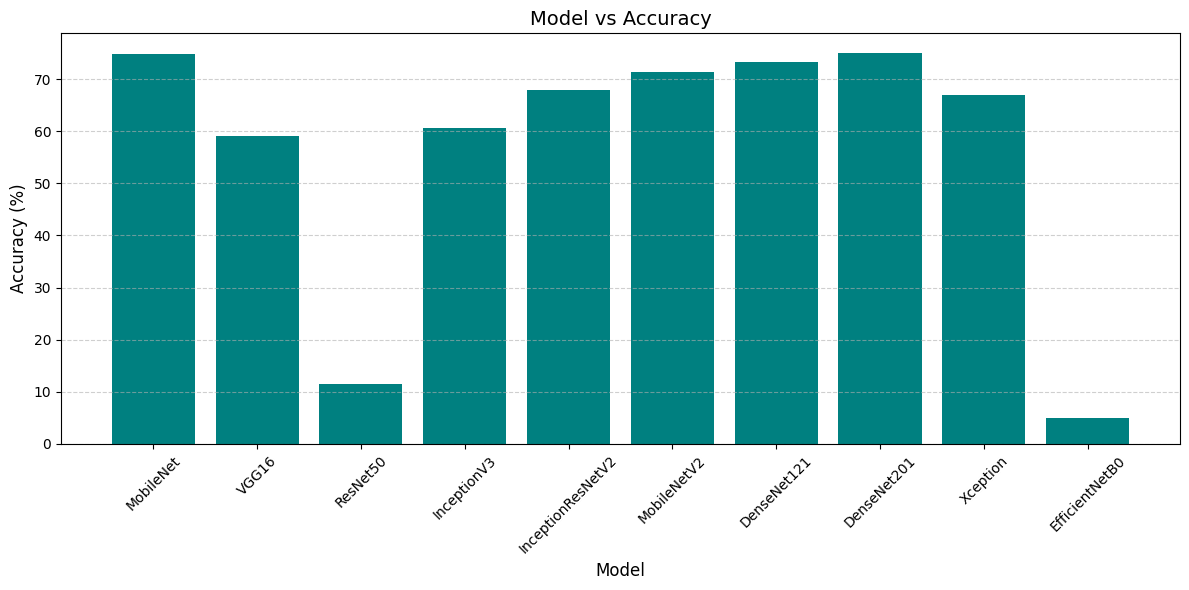

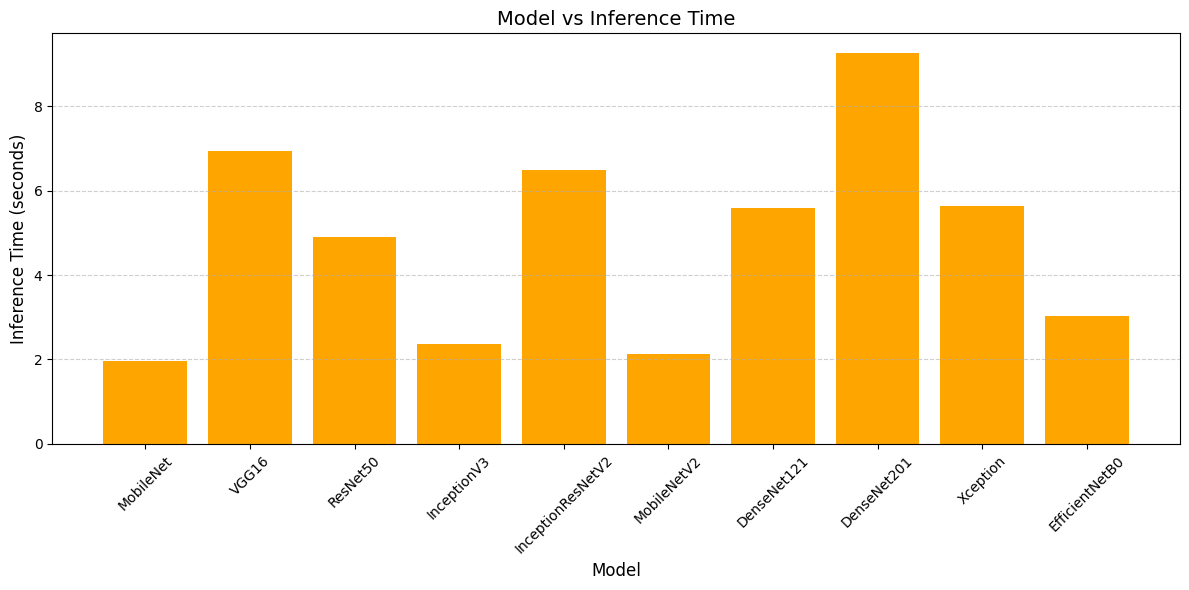

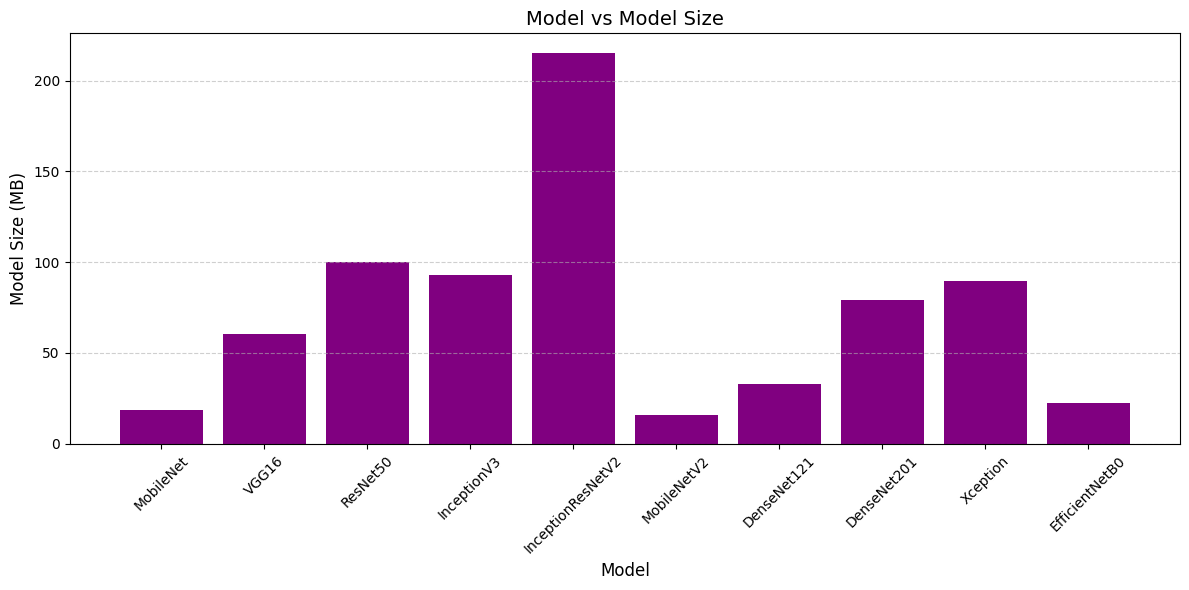

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Data from your table
data = {
    "Model": [
        "MobileNet", "VGG16", "ResNet50", "InceptionV3", "InceptionResNetV2",
        "MobileNetV2", "DenseNet121", "DenseNet201", "Xception", "EfficientNetB0"
    ],
    "Accuracy (%)": [74.75, 59.15, 11.5, 60.6, 67.95, 71.45, 73.25, 75.05, 67.05, 5],
    "Inference Time (s)": [1.97, 6.95, 4.9, 2.36, 6.5, 2.13, 5.6, 9.27, 5.64, 3.04],
    "Model Size (MB)": [18.39, 60.2, 100.05, 93.24, 215.35, 15.68, 32.91, 79.46, 89.65, 22.52]
}

# Create a DataFrame
df = pd.DataFrame(data)

# Set the figure size for better visibility
plt.figure(figsize=(12, 6))

# -----------------------------
# Plot 1: Model vs Accuracy
# -----------------------------
plt.bar(df["Model"], df["Accuracy (%)"], color='teal')
plt.title("Model vs Accuracy", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 2: Model vs Inference Time
# -----------------------------
plt.figure(figsize=(12, 6))
plt.bar(df["Model"], df["Inference Time (s)"], color='orange')
plt.title("Model vs Inference Time", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Inference Time (seconds)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# -----------------------------
# Plot 3: Model vs Model Size
# -----------------------------
plt.figure(figsize=(12, 6))
plt.bar(df["Model"], df["Model Size (MB)"], color='purple')
plt.title("Model vs Model Size", fontsize=14)
plt.xlabel("Model", fontsize=12)
plt.ylabel("Model Size (MB)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
